# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

## 1 **Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

## 2 **Objetivo**

Desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores

## 3 **Base de dados:**

- `Year_Birth`: Ano de nascimento do cliente.

- `Education`: Nível de escolaridade do cliente.

- `Marital_Status`: Estado civil do cliente.

- `Income`: Renda anual da família do cliente.

- `Kidhome`: Número de crianças na casa do cliente.

- `Recency`: Número de dias desde a última compra do cliente.

- `Complain`: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

- `MntWines`: Valor gasto em vinhos nos últimos 2 anos.

- `MntFruits`: Valor gasto em frutas nos últimos 2 anos.

- `MntMeatProducts`: Valor gasto em carnes nos últimos 2 anos.

- `MntFishProducts`: Valor gasto em peixes nos últimos 2 anos.

- `MntSweetProducts`: Valor gasto em doces nos últimos 2 anos.

- `MntGoldProds`: Valor gasto em produtos de ouro nos últimos 2 anos.

- `NumDealsPurchases`: Número de compras feitas com desconto

- `NumStorePurchases`: Número de compras feitas diretamente nas lojas.

- `NumWebVisitsMonth`: Número de visitas ao site da empresa no último mês.


**`WebPurchases`: Número de compras feitas pelo site da empresa.**

## 4  ETAPA 1: Preparação, Exploração e Limpeza dos Dados

### 4.1 Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

main_color = '#1f77b4'

# Paleta personalizada para matriz de confusão
cmap_azul = LinearSegmentedColormap.from_list(
    'cmap_azul',
    ['#ffffff', main_color]
)

### 4.2 Carregamento da base

In [2]:
base = pd.read_csv('marketing_campaign.csv', delimiter=';')
base.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


### 4.3 Análise inicial da base

In [3]:
# Verificando a quantidade de linhas e colunas
base.shape

(2240, 16)

In [4]:
#  Verificando os tipos de dados
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   str    
 2   Marital_Status     2240 non-null   str    
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13), str(2)
me

A base de dados foi carregada a partir do arquivo `marketing_campaign.csv`. Inicialmente, foram observadas as primeiras linhas, o tamanho da base e os tipos das variáveis, com o objetivo de compreender a estrutura dos dados antes das etapas de tratamento e modelagem.

### 4.4 Tratamento de valores ausentes

In [5]:
# Verificcando se existem valores nulos
base.isnull().sum()

Year_Birth            0
Education             0
Marital_Status        0
Income               24
Kidhome               0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumStorePurchases     0
NumWebVisitsMonth     0
Complain              0
WebPurchases          0
dtype: int64

In [6]:
# Tratando valores ausentes da coluna Income com a mediana
base['Income'] = base['Income'].fillna(base['Income'].median())

In [7]:
# Verificando se a substituição funcionou
base.isnull().sum()

Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Complain             0
WebPurchases         0
dtype: int64

### 4.5 Análise estatística descritiva

In [8]:
base.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52237.975446,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25037.955891,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35538.750000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68289.750000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


### 4.6 Análise e tratamento de outliers

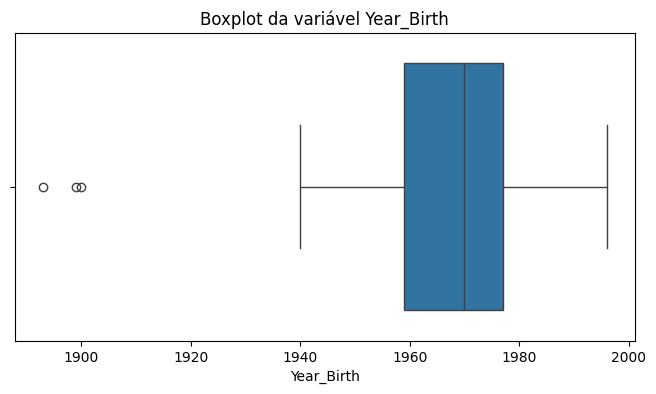

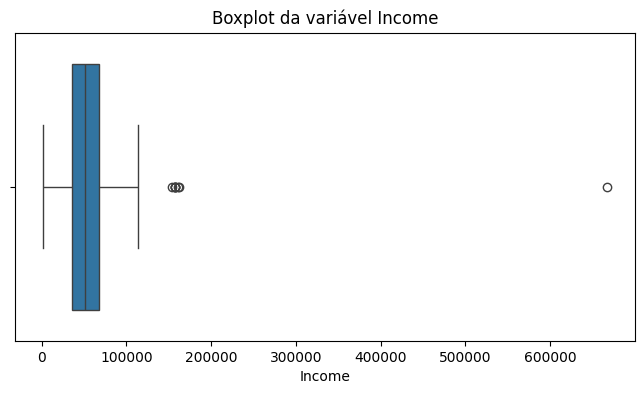

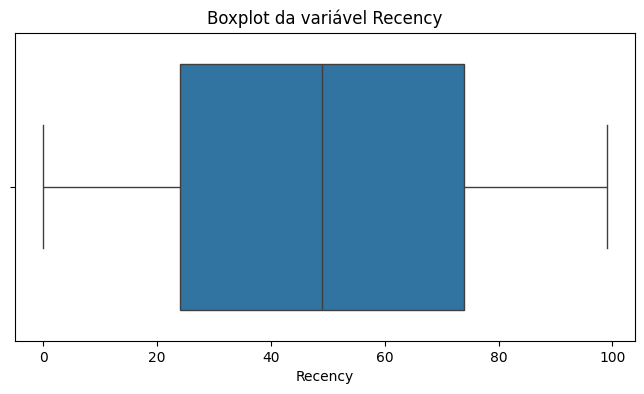

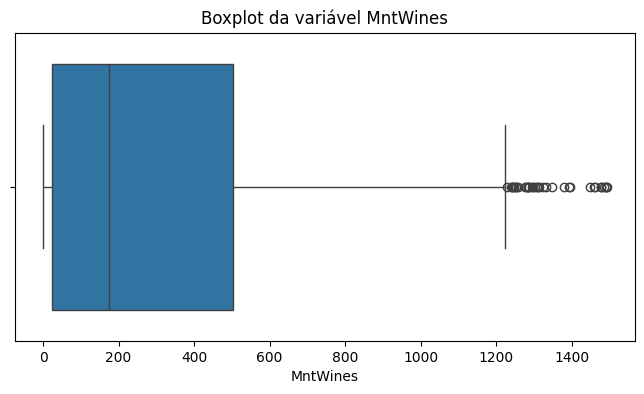

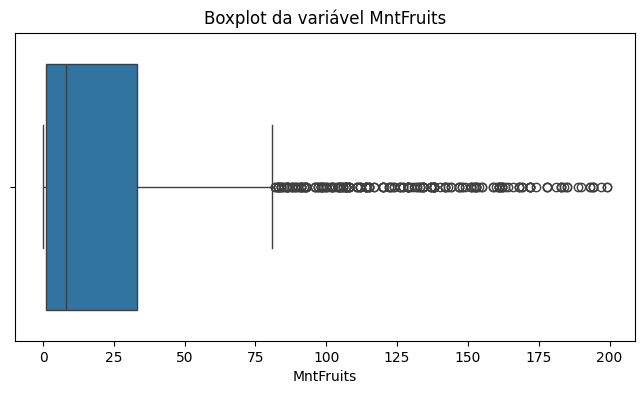

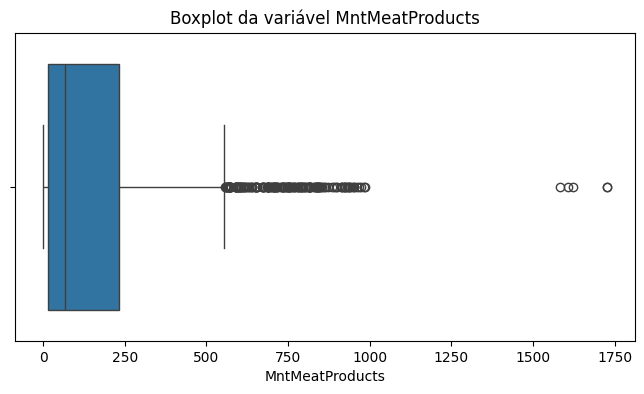

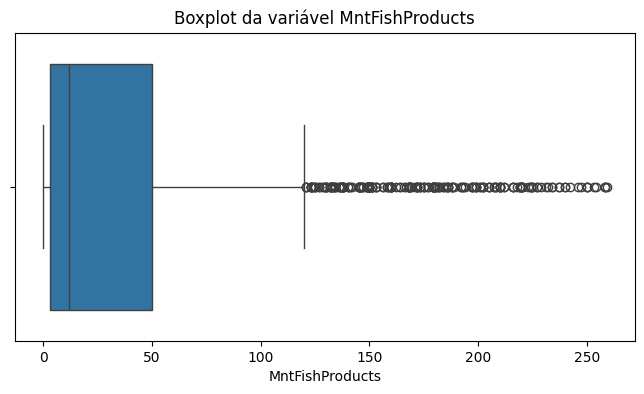

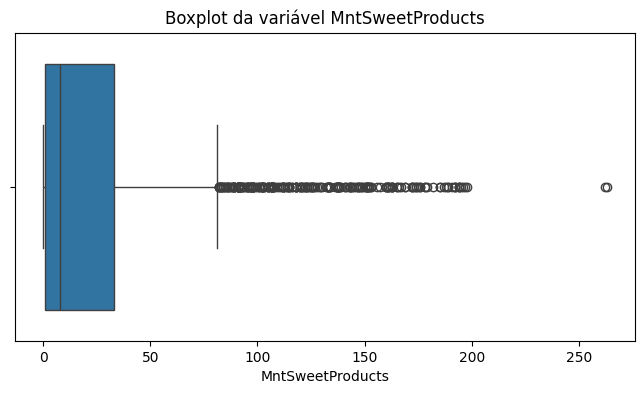

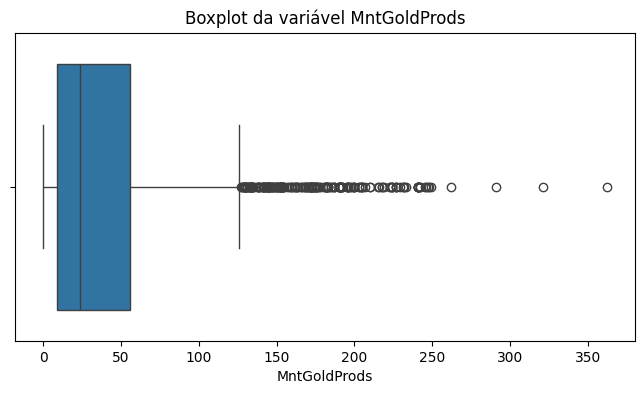

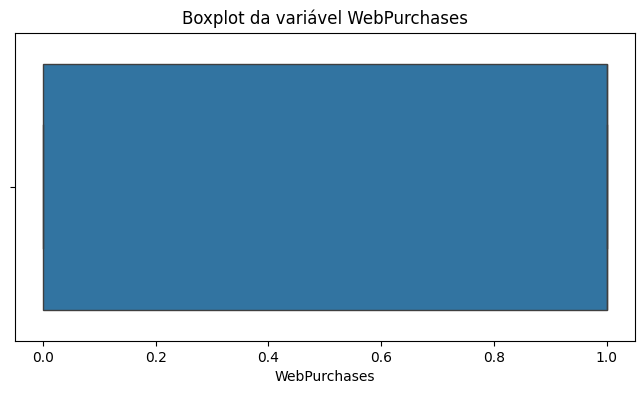

In [9]:
# Visualizando possíveis outliers em variáveis numéricas importantes
colunas_outliers = ['Year_Birth', 'Income', 'Recency', 'MntWines', 
                    'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                    'MntSweetProducts', 'MntGoldProds', 'WebPurchases']

for coluna in colunas_outliers:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=base[coluna])
    plt.title(f'Boxplot da variável {coluna}')
    plt.xlabel(coluna)
    plt.show()

A análise dos boxplots mostrou a presença de valores extremos em algumas variáveis numéricas. As variáveis relacionadas a gastos, como `MntWines`, `MntMeatProducts`, `MntFishProducts` e `MntGoldProds`, apresentam outliers, mas esses valores podem representar clientes com maior poder de compra ou maior frequência de consumo.

Por outro lado, as variáveis `Year_Birth` e `Income` exigem maior atenção. Em `Year_Birth`, foram identificados anos de nascimento muito antigos, que podem representar inconsistências. Já em `Income`, foi observado um valor extremamente alto em relação à maior parte dos clientes, podendo influenciar o desempenho do modelo, principalmente na etapa de padronização e aplicação do PCA.

In [10]:
# Verificando registros com ano de nascimento muito antigo
base[base['Year_Birth'] < 1920]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
192,1900,2n Cycle,Divorced,36640.0,1,99,15,6,8,7,4,25,2,5,1,0
239,1893,2n Cycle,Single,60182.0,0,23,8,0,5,7,0,2,2,4,0,0
339,1899,PhD,Together,83532.0,0,36,755,144,562,104,64,224,4,1,0,1


In [11]:
# Removendo registros com ano de nascimento anterior a 1920
base = base[base['Year_Birth'] >= 1920].copy()

In [12]:
base.shape

(2237, 16)

In [13]:
# Tratando outliers da variável Income usando o limite superior pelo método IQR
Q1 = base['Income'].quantile(0.25)
Q3 = base['Income'].quantile(0.75)
IQR = Q3 - Q1

limite_superior_income = Q3 + 1.5 * IQR

base['Income'] = np.where(
    base['Income'] > limite_superior_income,
    limite_superior_income,
    base['Income']
)

In [14]:
base.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,1968.901654,51854.814037,0.444345,49.104604,303.995530,26.270451,166.916853,37.523022,27.068842,43.968708,5.794367,5.319177,0.008941,0.503800
std,11.701917,20936.241476,0.538467,28.956073,336.574382,39.715972,225.661158,54.639909,41.293949,52.054318,3.250940,2.426386,0.094152,0.500097
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35523.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68281.000000,1.000000,74.000000,504.000000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,117418.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


### 4.7 Storytelling com gráficos

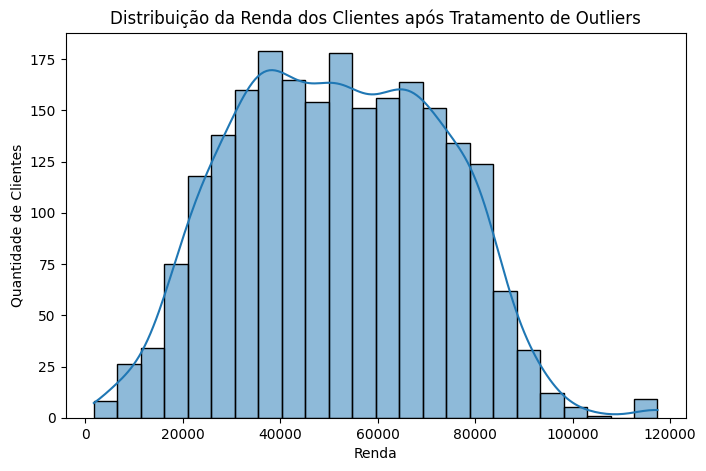

In [15]:
# Visualizando novamente a distribuição da renda após o tratamento
plt.figure(figsize=(8, 5))
sns.histplot(base['Income'], kde=True)
plt.title('Distribuição da Renda dos Clientes após Tratamento de Outliers')
plt.xlabel('Renda')
plt.ylabel('Quantidade de Clientes')
plt.show()

Após a análise dos outliers, optou-se por remover registros com `Year_Birth` anterior a 1920, por representarem idades muito elevadas e pouco prováveis para o contexto da base. Para a variável `Income`, foi aplicado um limite superior pelo método IQR, reduzindo o impacto de valores extremamente altos.

Os outliers das variáveis relacionadas a gastos foram mantidos, pois podem representar comportamentos reais de clientes com maior volume de compras. Essa decisão evita a perda de informações importantes para a previsão da intenção de compra web.

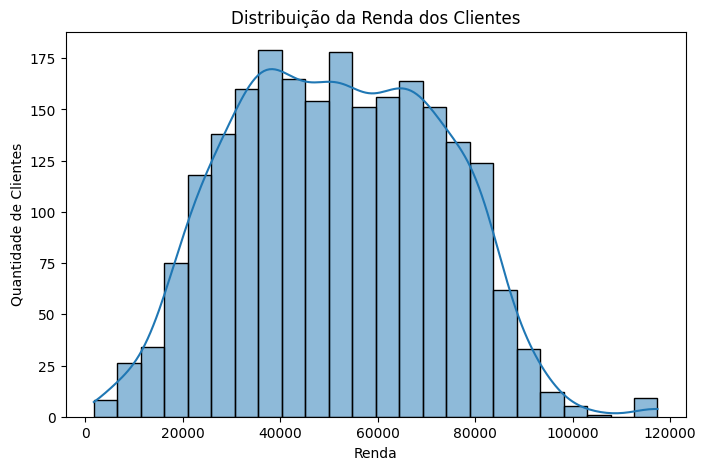

In [16]:
# Distribuição da renda dos clientes
plt.figure(figsize=(8, 5))
sns.histplot(base['Income'], kde=True)
plt.title('Distribuição da Renda dos Clientes')
plt.xlabel('Renda')
plt.ylabel('Quantidade de Clientes')
plt.show()

A distribuição da renda após o tratamento dos outliers permite observar melhor o perfil econômico dos clientes presentes na base. Essa análise é importante porque a renda pode influenciar o comportamento de compra e a capacidade de consumo no e-commerce.

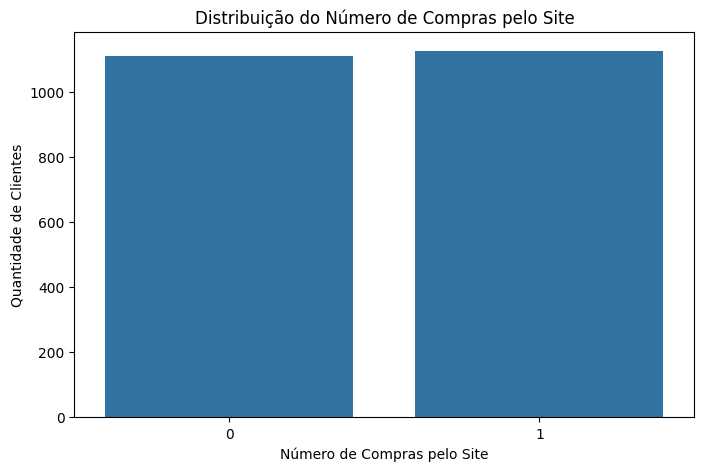

In [17]:
# Distribuição das compras realizadas pelo site
plt.figure(figsize=(8, 5))
sns.countplot(data=base, x='WebPurchases')
plt.title('Distribuição do Número de Compras pelo Site')
plt.xlabel('Número de Compras pelo Site')
plt.ylabel('Quantidade de Clientes')
plt.show()

O gráfico mostra como os clientes estão distribuídos em relação ao número de compras realizadas pelo site. Essa informação é importante porque a variável `WebPurchases` será utilizada como base para criar a variável alvo do modelo.

## 5 ETAPA 2: Pré-processamento e PCA

### 5.1 Criação da variável alvo

In [18]:
# Criando a variável alvo
base['Intencao_Compra_Web'] = base['WebPurchases']

base[['WebPurchases', 'Intencao_Compra_Web']].head()# seu código aqui

,WebPurchases,Intencao_Compra_Web
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1


In [19]:
# Verificando a distribuição da variável alvo
base['Intencao_Compra_Web'].value_counts()

Intencao_Compra_Web
1    1127
0    1110
Name: count, dtype: int64

A variável `WebPurchases` já está representada em formato binário, com valores 0 e 1. Por isso, ela foi utilizada como base para a criação da variável alvo `Intencao_Compra_Web`, em que 1 indica cliente com compra realizada pelo site e 0 indica cliente sem compra pelo site.

### 5.2 Análise de correlação

In [20]:
# Selecionando variáveis numéricas
numeric_variables = base.select_dtypes(include=['int64', 'float64']).columns
numeric_variables

Index(['Year_Birth', 'Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain',
       'WebPurchases', 'Intencao_Compra_Web'],
      dtype='str')

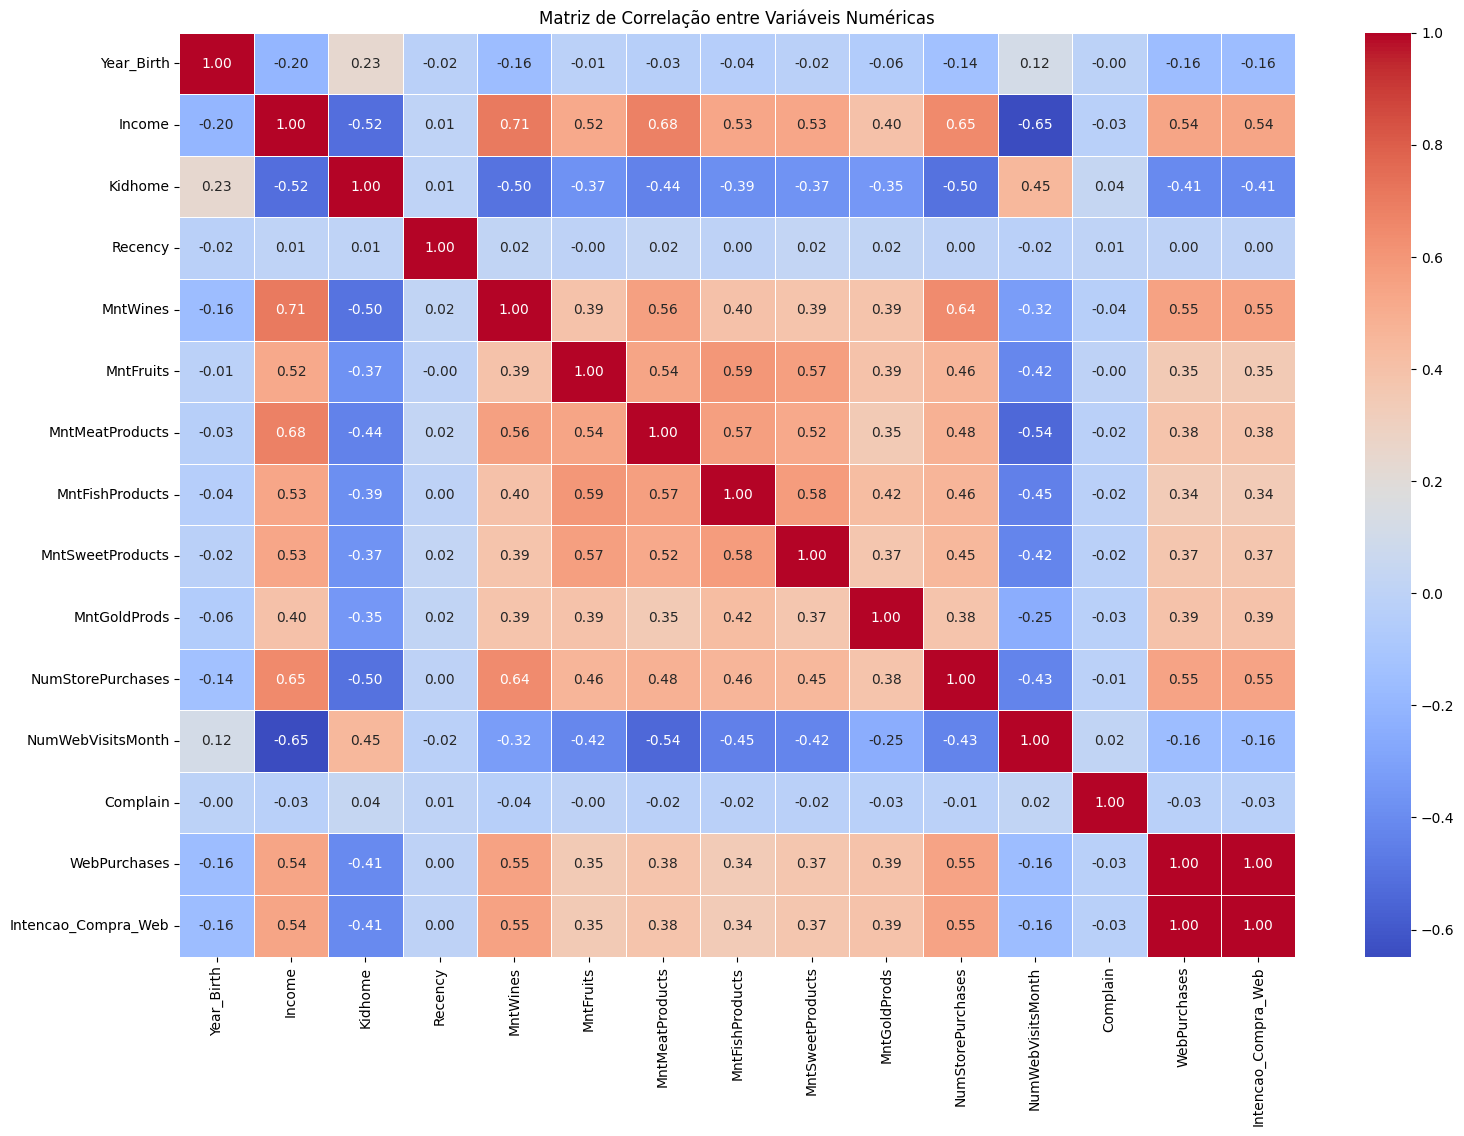

In [21]:
# Matriz de correlação com tamanho maior
corr = base[numeric_variables].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

A análise de correlação mostrou que `WebPurchases` possui correlação perfeita com `Intencao_Compra_Web`, pois a variável alvo foi criada a partir dela. Por isso, `WebPurchases` será removida das variáveis explicativas, evitando vazamento de dados no modelo. Entre as demais variáveis, destacam-se `MntWines`, `NumStorePurchases` e `Income`, que apresentam correlação positiva com a intenção de compra web.

In [22]:
# Correlação das variáveis com a intenção de compra web
target_correlation = base[numeric_variables].corr()['Intencao_Compra_Web'].sort_values(ascending=False)
target_correlation

WebPurchases           1.000000
Intencao_Compra_Web    1.000000
MntWines               0.549889
NumStorePurchases      0.546522
Income                 0.541617
MntGoldProds           0.392923
MntMeatProducts        0.384419
MntSweetProducts       0.369100
MntFruits              0.347958
MntFishProducts        0.338049
Recency                0.000899
Complain              -0.029217
NumWebVisitsMonth     -0.160957
Year_Birth            -0.162027
Kidhome               -0.408184
Name: Intencao_Compra_Web, dtype: float64

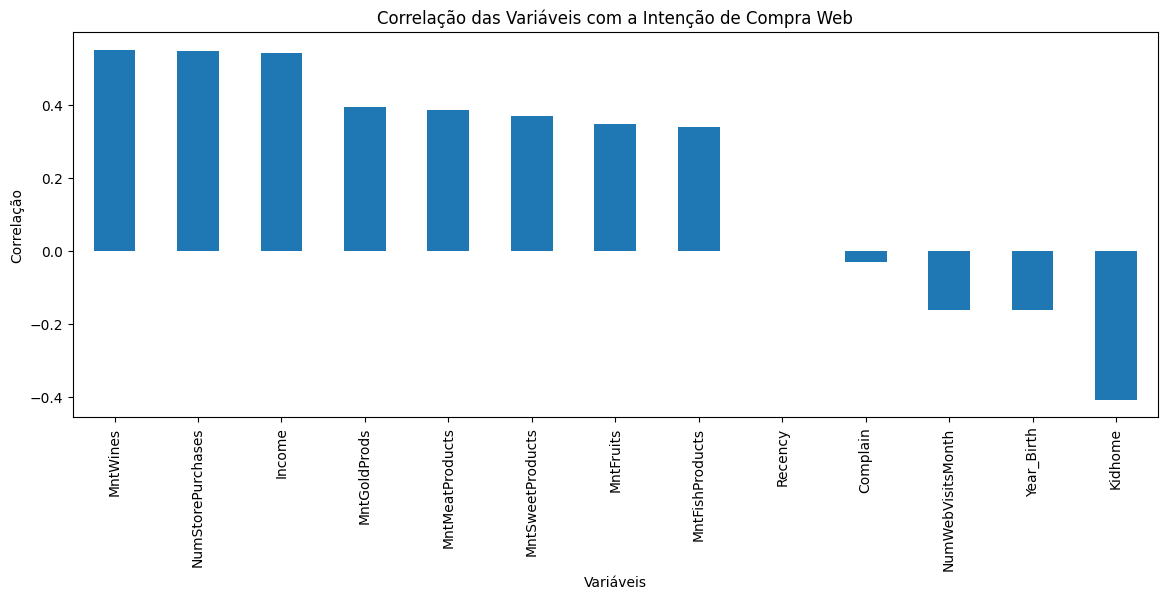

In [23]:
# Gráfico das correlações com a variável alvo, removendo a variável original WebPurchases
target_correlation.drop(['Intencao_Compra_Web', 'WebPurchases']).plot(
    kind='bar',
    figsize=(14, 5)
)

plt.title('Correlação das Variáveis com a Intenção de Compra Web')
plt.xlabel('Variáveis')
plt.ylabel('Correlação')
plt.show()

A análise de correlação permite observar quais variáveis apresentam maior relação com a intenção de compra web. Essa etapa auxilia na identificação de atributos que podem contribuir para o desempenho dos modelos preditivos.

### 5.3 Separação entre variáveis explicativas e variável alvo

In [24]:
# Separando variáveis explicativas e variável alvo
# WebPurchases será removida porque foi usada para criar a variável alvo
X = base.drop(columns=['WebPurchases', 'Intencao_Compra_Web'])
y = base['Intencao_Compra_Web']

X.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0


In [25]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Intencao_Compra_Web, dtype: int64

### 5.4 Codificação das variáveis categóricas

In [26]:
# Transformando variáveis categóricas em variáveis numéricas
X = pd.get_dummies(X, drop_first=True)

X.head()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,58138.0,0,58,635,88,546,172,88,88,...,True,False,False,False,False,False,True,False,False,False
1,1954,46344.0,1,38,11,1,6,2,1,6,...,True,False,False,False,False,False,True,False,False,False
2,1965,71613.0,0,26,426,49,127,111,21,42,...,True,False,False,False,False,False,False,True,False,False
3,1984,26646.0,1,26,11,4,20,10,3,5,...,True,False,False,False,False,False,False,True,False,False
4,1981,58293.0,1,94,173,43,118,46,27,15,...,False,False,True,False,False,True,False,False,False,False


In [27]:
X.shape

(2237, 24)

As variáveis categóricas foram transformadas em variáveis numéricas por meio da técnica `get_dummies`. Essa etapa é necessária porque os modelos de machine learning trabalham com dados numéricos.

### 5.5 Separação entre treino e teste

In [28]:
# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

### 5.6 Padronização dos dados

In [29]:
# Padronizando os dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Os dados foram separados em treino e teste para avaliar o desempenho dos modelos em dados não vistos. Em seguida, foi aplicada a padronização, etapa importante antes do PCA, pois essa técnica é sensível à escala das variáveis.

### 5.7 Aplicação do PCA

In [30]:
# Aplicando PCA inicial com 10 componentes
pca = PCA(n_components=10)

pca.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

In [31]:
# Variância explicada por componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada

cumulative_variance = explained_variance.cumsum()

print(explained_variance)
print(cumulative_variance)

[0.2223314  0.07562946 0.06297788 0.05662628 0.05478691 0.04895344
 0.04564011 0.04534781 0.04317027 0.0419818 ]
[0.2223314  0.29796086 0.36093874 0.41756502 0.47235193 0.52130537
 0.56694548 0.61229329 0.65546356 0.69744536]


O gráfico de variância explicada acumulada mostra quanto da variabilidade original dos dados é preservada conforme aumentamos o número de componentes principais. O objetivo do PCA é reduzir a dimensionalidade da base, mantendo a maior parte possível das informações relevantes.

In [32]:
# Identificando quantos componentes explicam pelo menos 90% da variância
pca_completo = PCA()
pca_completo.fit(X_train_scaled)

variancia_acumulada = pca_completo.explained_variance_ratio_.cumsum()

n_componentes = np.argmax(variancia_acumulada >= 0.90) + 1

print(f'Número de componentes para explicar pelo menos 90% da variância: {n_componentes}')

Número de componentes para explicar pelo menos 90% da variância: 16


Após a análise da variância explicada acumulada, foi definida a quantidade de componentes principais necessária para preservar pelo menos 90% da variabilidade dos dados. Assim, a base foi reduzida para um número menor de componentes, mantendo boa parte da informação original.

In [33]:
# Aplicando PCA final com a quantidade de componentes escolhida
pca_final = PCA(n_components=n_componentes)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

X_train_pca.shape

(1565, 16)

Após identificar que 16 componentes principais explicam pelo menos 90% da variância dos dados, o PCA final foi aplicado nas bases de treino e teste. Dessa forma, os modelos serão treinados com uma versão reduzida da base, mantendo a maior parte da informação original.

## 6 ETAPA 3: Modelagem

### 6.1 Regressão Logística com PCA

In [34]:
# Modelo 1: Regressão Logística
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

modelo_lr.fit(X_train_pca, y_train)

y_pred_lr = modelo_lr.predict(X_test_pca)

### 6.2 Random Forest com PCA

In [35]:
# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train_pca, y_train)

y_pred_rf = modelo_rf.predict(X_test_pca)

Foram utilizados dois modelos de classificação: Regressão Logística e Random Forest. A Regressão Logística é um modelo tradicional para problemas de classificação binária, enquanto o Random Forest é um modelo baseado em árvores de decisão, capaz de capturar relações mais complexas entre as variáveis.

## 7 ETAPA 4: Avaliação dos Modelos

### 7.1 Avaliação da Regressão Logística

In [36]:
# Função para avaliar os modelos
def avaliar_modelo(nome_modelo, y_test, y_pred):
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f'Modelo: {nome_modelo}')
    print(f'Acurácia: {acuracia:.4f}')
    print(f'Precisão: {precisao:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print('\nRelatório de Classificação:')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return {
        'Modelo': nome_modelo,
        'Acurácia': acuracia,
        'Precisão': precisao,
        'Recall': recall,
        'F1-score': f1
    }

In [37]:
# Avaliando a Regressão Logística
resultado_lr = avaliar_modelo('Regressão Logística com PCA', y_test, y_pred_lr)

Modelo: Regressão Logística com PCA
Acurácia: 0.8363
Precisão: 0.8567
Recall: 0.8112
F1-score: 0.8333

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       333
           1       0.86      0.81      0.83       339

    accuracy                           0.84       672
   macro avg       0.84      0.84      0.84       672
weighted avg       0.84      0.84      0.84       672



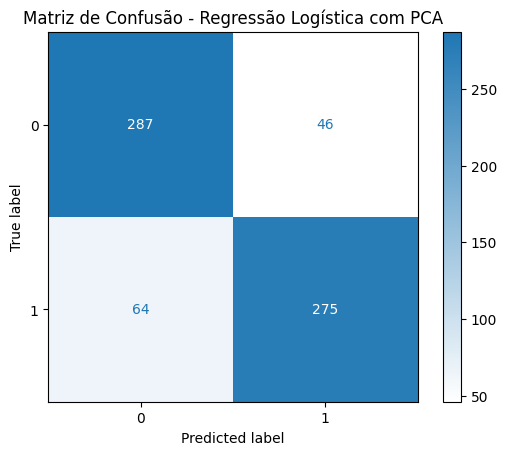

In [38]:
# Matriz de confusão - Regressão Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap=cmap_azul,  values_format='d')
plt.title('Matriz de Confusão - Regressão Logística com PCA')
plt.show()

### 7.2 Avaliação do Random Forest

In [39]:
# Avaliando o Random Forest
resultado_rf = avaliar_modelo('Random Forest com PCA', y_test, y_pred_rf)

Modelo: Random Forest com PCA
Acurácia: 0.8869
Precisão: 0.8643
Recall: 0.9204
F1-score: 0.8914

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       333
           1       0.86      0.92      0.89       339

    accuracy                           0.89       672
   macro avg       0.89      0.89      0.89       672
weighted avg       0.89      0.89      0.89       672



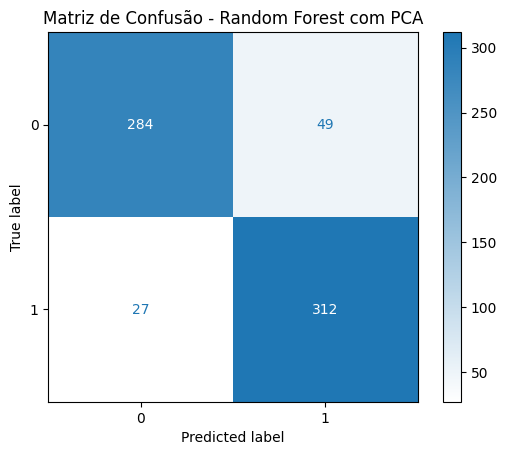

In [40]:
# Matriz de confusão - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap=cmap_azul,  values_format='d')
plt.title('Matriz de Confusão - Random Forest com PCA')
plt.show()

### 7.3 Comparação dos modelos

In [41]:
# Comparando os resultados dos modelos
resultados = pd.DataFrame([resultado_lr, resultado_rf])

resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística com PCA,0.836310,0.856698,0.811209,0.833333
1,Random Forest com PCA,0.886905,0.864266,0.920354,0.891429


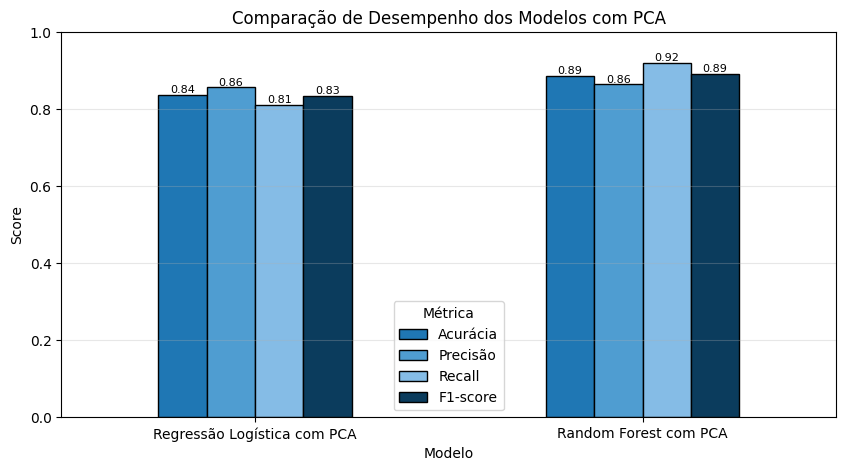

In [42]:
# Gráfico comparativo dos modelos
cores_metricas = ['#1f77b4', '#4f9dd1', '#85bce6', '#0b3c5d']

ax = resultados.set_index('Modelo')[['Acurácia', 'Precisão', 'Recall', 'F1-score']].plot(
    kind='bar',
    figsize=(10, 5),
    color=cores_metricas,
    edgecolor='black'
)

plt.title('Comparação de Desempenho dos Modelos com PCA')
plt.xlabel('Modelo')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Métrica')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)

plt.show()

A avaliação dos modelos foi realizada utilizando acurácia, precisão, recall, F1-score e matriz de confusão. Essas métricas permitem analisar não apenas a quantidade geral de acertos, mas também a capacidade dos modelos de identificar corretamente clientes com e sem intenção de compra web.

A matriz de confusão complementa a análise ao mostrar os acertos e erros de classificação de cada modelo.

## 8 Conclusão

Com base nos resultados obtidos, foi possível desenvolver um projeto de machine learning para prever a intenção de compra de clientes em uma loja web. O projeto passou pelas etapas de exploração, limpeza, tratamento de valores ausentes, análise de outliers, pré-processamento, aplicação do PCA, modelagem e avaliação.

A técnica de PCA foi utilizada para reduzir a dimensionalidade dos dados, mantendo pelo menos 90% da variância original. Após essa transformação, foram treinados dois modelos de classificação: Regressão Logística e Random Forest.

Ao comparar os resultados, o modelo Random Forest com PCA apresentou o melhor desempenho geral, com acurácia de aproximadamente 0,887 e F1-score de aproximadamente 0,891. Além disso, o modelo também apresentou bom recall, indicando boa capacidade de identificar clientes com intenção de compra web.

Dessa forma, o projeto atende ao objetivo proposto, aplicando técnicas de pré-processamento, redução de dimensionalidade e classificação binária com base nos conceitos trabalhados em aula.